In [111]:
all_datasets = ['real_data/data_batteries_ecfp_descriptor', 'synthetic_data/qm9_simple_linear6', 'synthetic_data/qm9_piecewise_linear_6','synthetic_data/qm9_nonlinear_6']
all_datasets = ['gt_synthetic_data/qm9_simple_linear6', 'gt_synthetic_data/qm9_piecewise_linear_6','gt_synthetic_data/qm9_nonlinear_6']
dataset_names = [ 'QM9 Simple Linear', 'QM9 Piecewise Linear', 'QM9 Nonlinear']
metrics = {}
cf_validity = {}
cf_similarity = {}

import pandas as pd
import pickle

for i, dataset in enumerate(all_datasets):
    with open(f'../results/{dataset}/explanations/analysis/metrics_results.pickle', 'rb') as f:
        results = pickle.load(f)
    metrics[dataset_names[i]] = results
    with open(f'../results/{dataset}/explanations/analysis/cf_validity_results.pickle', 'rb') as f:
        results = pickle.load(f)
    cf_validity[dataset_names[i]] = results
    with open(f'../results/{dataset}/explanations/analysis/cf_similarity_results.pickle', 'rb') as f:
        results = pickle.load(f)
    cf_similarity[dataset_names[i]] = results

metrics

{'QM9 Simple Linear': {'lime': {'pgi_mean': np.float64(20.57689116969892),
   'pgu_mean': np.float64(0.725750301956934),
   'pgi_std': np.float64(0.6589582638357161),
   'pgu_std': np.float64(0.03647146455204254),
   'fa_mean': np.float64(1.0),
   'fa_std': np.float64(0.0),
   'fa_interactions_mean': None,
   'fa_interactions_std': None},
  'shap': {'pgi_mean': np.float64(20.673267588960446),
   'pgu_mean': np.float64(0.7241484400076871),
   'pgi_std': np.float64(0.6959413019103843),
   'pgu_std': np.float64(0.04199346123291509),
   'fa_mean': np.float64(1.0),
   'fa_std': np.float64(0.0),
   'fa_interactions_mean': None,
   'fa_interactions_std': None},
  'shapiq1': {'pgi_mean': np.float64(20.69575582034375),
   'pgu_mean': np.float64(0.7215203928061894),
   'pgi_std': np.float64(0.6530696312607591),
   'pgu_std': np.float64(0.040464275997857464),
   'fa_mean': np.float64(1.0),
   'fa_std': np.float64(0.0),
   'fa_interactions_mean': None,
   'fa_interactions_std': None},
  'shapiq2':

In [102]:
def reshape_results_to_wide_format(df: pd.DataFrame) -> pd.DataFrame:
    """
    Transforms a long-format DataFrame of results into a wide-format DataFrame.

    The resulting DataFrame will have 'method' as the index, and a single column
    for each combination of 'dataset' and 'metric'.

    Args:
        df (pd.DataFrame): A DataFrame with columns ['method', 'dataset', 'metric', 'value'].

    Returns:
        pd.DataFrame: The reshaped, wide-format DataFrame.
    """
    pivoted_df = df.pivot_table(
        index='method',
        columns=['dataset', 'metric'],
        values='value'
    )

    pivoted_df.columns = [f"{col[0]}_{col[1]}" for col in pivoted_df.columns]
    return pivoted_df

In [103]:
cf_validity

{'Batteries': {'meg': np.float64(0.3423529411764706),
  'mmace': 0.6537254901960784},
 'QM9 Simple Linear': {'meg': np.float64(0.8846), 'mmace': 0.956},
 'QM9 Piecewise Linear': {'meg': np.float64(0.938), 'mmace': 0.9654},
 'QM9 Nonlinear': {'meg': np.float64(0.9668), 'mmace': 0.9938}}

In [112]:
cf_similarity

{'QM9 Simple Linear': {'meg': (np.float64(0.33726825283020573),
   np.float64(0.10822305062869123)),
  'mmace': (np.float64(0.307629791093913), np.float64(0.157437806882057))},
 'QM9 Piecewise Linear': {'meg': (np.float64(0.35948105702332006),
   np.float64(0.09800780305015924)),
  'mmace': (np.float64(0.3200352223198329), np.float64(0.15615716123709739))},
 'QM9 Nonlinear': {'meg': (np.float64(0.3656236833393694),
   np.float64(0.09468384072508454)),
  'mmace': (np.float64(0.3099621721845715), np.float64(0.13976511064783367))}}

In [106]:
df_validity = {'method': [], 'dataset': [], 'metric': [], 'value': []}
for k in cf_validity:
    for method in cf_validity[k]:
        df_validity['method'].append(method)
        df_validity['dataset'].append(k)
        df_validity['metric'].append('validity')
        df_validity['value'].append(cf_validity[k][method])
df_validity = pd.DataFrame(df_validity)
df_validity = reshape_results_to_wide_format(df_validity)
df_validity = df_validity[[
    'QM9 Simple Linear_validity',
    'QM9 Piecewise Linear_validity',
    'QM9 Nonlinear_validity',
    'Batteries_validity',
]]
df_validity = df_validity.rename(
    columns={
        'QM9 Simple Linear_validity': 'QM9 Simple Linear',
        'QM9 Piecewise Linear_validity': 'QM9 Piecewise Linear',
        'QM9 Nonlinear_validity': 'QM9 Nonlinear',
    }
)
df_validity = df_validity.T
df_validity = df_validity[['mmace', 'meg']]
print(df_validity.style.format(precision=2).to_latex())

\begin{tabular}{lrr}
method & mmace & meg \\
QM9 Simple Linear & 0.96 & 0.88 \\
QM9 Piecewise Linear & 0.97 & 0.94 \\
QM9 Nonlinear & 0.99 & 0.97 \\
Batteries_validity & 0.65 & 0.34 \\
\end{tabular}



In [113]:
df_validity = {'method': [], 'dataset': [], 'metric': [], 'value': []}
for k in cf_similarity:
    for method in cf_similarity[k]:
        df_validity['method'].append(method)
        df_validity['dataset'].append(k)
        df_validity['method'].append(method)
        df_validity['dataset'].append(k)
        df_validity['metric'].append('similarity')
        df_validity['metric'].append('similarity std')
        df_validity['value'].append(cf_similarity[k][method][0])
        df_validity['value'].append(cf_similarity[k][method][1])
df_validity = pd.DataFrame(df_validity)
df_validity = reshape_results_to_wide_format(df_validity)
df_validity_mean = df_validity[[
    'QM9 Simple Linear_similarity',
    'QM9 Piecewise Linear_similarity',
    'QM9 Nonlinear_similarity',
    #'Batteries_similarity'
]]
df_validity_mean = df_validity_mean.rename(
    columns={
        'QM9 Simple Linear_similarity': 'QM9 Simple Linear',
        'QM9 Piecewise Linear_similarity': 'QM9 Piecewise Linear',
        'QM9 Nonlinear_similarity': 'QM9 Nonlinear',
        #'Batteries_similarity': 'Batteries',
    }
)
df_validity_std = df_validity[[
    'QM9 Simple Linear_similarity std',
    'QM9 Piecewise Linear_similarity std',
    'QM9 Nonlinear_similarity std',
    #'Batteries_similarity std'
]]
df_validity_std = df_validity_std.rename(
    columns={
        'QM9 Simple Linear_similarity std': 'QM9 Simple Linear',
        'QM9 Piecewise Linear_similarity std': 'QM9 Piecewise Linear',
        'QM9 Nonlinear_similarity std': 'QM9 Nonlinear',
        #'Batteries_similarity std': 'Batteries',
    }
)
df_mean_str = df_validity_mean.map('{:.2f}'.format)
df_std_str = df_validity_std.map('{:.2f}'.format)
df_validity = df_mean_str + '(' + df_std_str + ')'
df_validity = df_validity.T
df_validity = df_validity[['mmace', 'meg']]
print(df_validity.style.format(precision=2).to_latex())

\begin{tabular}{lll}
method & mmace & meg \\
QM9 Simple Linear & 0.31(0.16) & 0.34(0.11) \\
QM9 Piecewise Linear & 0.32(0.16) & 0.36(0.10) \\
QM9 Nonlinear & 0.31(0.14) & 0.37(0.09) \\
\end{tabular}



In [75]:

metrics_dataframe = {'method': [], 'dataset': [], 'metric': [], 'value': []}
cf_validity_dataframe = {'method': [], 'dataset': [], 'metric': []}
cf_similarity_dataframe = {'method': [], 'dataset': [], 'metric': []}

for dataset in dataset_names:
    for method, method_results in metrics[dataset].items():

        metrics_dataframe['method'].append(method)
        metrics_dataframe['dataset'].append(dataset)
        metrics_dataframe['method'].append(method)
        metrics_dataframe['dataset'].append(dataset)
        metrics_dataframe['method'].append(method)
        metrics_dataframe['dataset'].append(dataset)
        metrics_dataframe['method'].append(method)
        metrics_dataframe['dataset'].append(dataset)
        metrics_dataframe['method'].append(method)
        metrics_dataframe['metric'].append('pgi')
        metrics_dataframe['value'].append(method_results['pgi_mean'])
        metrics_dataframe['metric'].append('pgi std')
        metrics_dataframe['value'].append(method_results['pgi_std'])
        metrics_dataframe['metric'].append('pgu')
        metrics_dataframe['value'].append(method_results['pgu_mean'])
        metrics_dataframe['metric'].append('pgu std')
        metrics_dataframe['value'].append(method_results['pgu_std'])
        if 'fa_mean' in method_results:
            metrics_dataframe['dataset'].append(dataset)
            metrics_dataframe['method'].append(method)
            metrics_dataframe['dataset'].append(dataset)
            metrics_dataframe['method'].append(method)
            metrics_dataframe['dataset'].append(dataset)
            metrics_dataframe['metric'].append('fa')
            metrics_dataframe['value'].append(method_results['fa_mean'])
            metrics_dataframe['metric'].append('fa std')
            metrics_dataframe['value'].append(method_results['fa_std'])
            metrics_dataframe['metric'].append('fa interactions')
            metrics_dataframe['value'].append(method_results['fa_interactions_mean'])

{'method': ['lime',
  'lime',
  'lime',
  'lime',
  'lime',
  'lime',
  'lime',
  'shap',
  'shap',
  'shap',
  'shap',
  'shap',
  'shap',
  'shap',
  'shapiq1',
  'shapiq1',
  'shapiq1',
  'shapiq1',
  'shapiq1',
  'shapiq1',
  'shapiq1',
  'shapiq2',
  'shapiq2',
  'shapiq2',
  'shapiq2',
  'shapiq2',
  'shapiq2',
  'shapiq2',
  'meg',
  'meg',
  'meg',
  'meg',
  'meg',
  'meg',
  'meg',
  'mmace',
  'mmace',
  'mmace',
  'mmace',
  'mmace',
  'mmace',
  'mmace',
  'aggregated',
  'aggregated',
  'aggregated',
  'aggregated',
  'aggregated',
  'aggregated',
  'aggregated',
  'lime',
  'lime',
  'lime',
  'lime',
  'lime',
  'lime',
  'lime',
  'shap',
  'shap',
  'shap',
  'shap',
  'shap',
  'shap',
  'shap',
  'shapiq1',
  'shapiq1',
  'shapiq1',
  'shapiq1',
  'shapiq1',
  'shapiq1',
  'shapiq1',
  'shapiq2',
  'shapiq2',
  'shapiq2',
  'shapiq2',
  'shapiq2',
  'shapiq2',
  'shapiq2',
  'meg',
  'meg',
  'meg',
  'meg',
  'meg',
  'meg',
  'meg',
  'mmace',
  'mmace',
  'mmace'

In [76]:
for k, v in metrics_dataframe.items():
    print(k, len(v))

method 147
dataset 147
metric 147
value 147


In [77]:
metrics_dataframe = pd.DataFrame(metrics_dataframe)

In [78]:
metrics_dataframe

,method,dataset,metric,value
0,lime,QM9 Simple Linear,pgi,20.576891
1,lime,QM9 Simple Linear,pgi std,0.658958
2,lime,QM9 Simple Linear,pgu,0.725750
3,lime,QM9 Simple Linear,pgu std,0.036471
4,lime,QM9 Simple Linear,fa,1.000000
...,...,...,...,...
142,aggregated,QM9 Nonlinear,pgu,1.004151
143,aggregated,QM9 Nonlinear,pgu std,0.566165
144,aggregated,QM9 Nonlinear,fa,0.982796
145,aggregated,QM9 Nonlinear,fa std,0.040896


In [80]:
metrics_dataframe = reshape_results_to_wide_format(metrics_dataframe)

In [81]:
metrics_dataframe

,QM9 Nonlinear_fa,QM9 Nonlinear_fa interactions,QM9 Nonlinear_fa std,QM9 Nonlinear_pgi,QM9 Nonlinear_pgi std,QM9 Nonlinear_pgu,QM9 Nonlinear_pgu std,QM9 Piecewise Linear_fa,QM9 Piecewise Linear_fa interactions,QM9 Piecewise Linear_fa std,...,QM9 Piecewise Linear_pgi std,QM9 Piecewise Linear_pgu,QM9 Piecewise Linear_pgu std,QM9 Simple Linear_fa,QM9 Simple Linear_fa interactions,QM9 Simple Linear_fa std,QM9 Simple Linear_pgi,QM9 Simple Linear_pgi std,QM9 Simple Linear_pgu,QM9 Simple Linear_pgu std
method,,,,,,,,,,,,,,,,,,,,,
aggregated,0.982796,NaN,0.040896,18.555410,0.859985,1.004151,0.566165,0.970430,NaN,0.046265,...,0.972934,0.683421,0.140683,0.994086,NaN,0.016865,20.607098,0.775499,0.878749,0.269127
lime,0.998118,NaN,0.005645,18.552663,0.903898,0.743151,0.106918,1.000000,NaN,0.000000,...,0.835274,0.931970,0.075425,1.000000,NaN,0.000000,20.576891,0.658958,0.725750,0.036471
meg,0.833871,NaN,0.047631,18.298294,0.908452,3.674829,0.482266,0.827957,NaN,0.077660,...,0.856872,2.040604,0.507804,0.859409,NaN,0.051471,20.351580,0.538847,2.937963,0.599954
mmace,0.920430,NaN,0.054221,18.428118,0.930744,2.021502,0.715999,0.909409,NaN,0.072968,...,0.901023,1.405395,0.411106,0.915054,NaN,0.029428,20.512800,0.577783,2.156819,0.370434
shap,1.000000,NaN,0.000000,18.492780,0.839889,0.697216,0.049847,1.000000,NaN,0.000000,...,1.042799,0.572323,0.079973,1.000000,NaN,0.000000,20.673268,0.695941,0.724148,0.041993
shapiq1,1.000000,NaN,0.000000,18.477188,1.005636,0.717487,0.063850,1.000000,NaN,0.000000,...,1.038561,0.571915,0.080802,1.000000,NaN,0.000000,20.695756,0.653070,0.721520,0.040464
shapiq2,0.962352,0.968115,0.057305,18.272644,0.961694,8.669478,1.563902,0.972536,0.971611,0.023801,...,1.046386,6.337218,1.642413,0.998513,0.998513,0.003065,20.686901,0.611351,5.537138,0.307004


In [82]:
metrics_df_mean = metrics_dataframe[[
    'QM9 Simple Linear_fa', 'QM9 Simple Linear_pgi', 'QM9 Simple Linear_pgu',
    'QM9 Piecewise Linear_fa', 'QM9 Piecewise Linear_pgi', 'QM9 Piecewise Linear_pgu',
   'QM9 Nonlinear_fa', 'QM9 Nonlinear_pgi', 'QM9 Nonlinear_pgu',
    # 'Batteries_pgi', 'Batteries_pgu',

]]
metrics_df_std = metrics_dataframe[[
    'QM9 Simple Linear_fa std', 'QM9 Simple Linear_pgi std', 'QM9 Simple Linear_pgu std',
    'QM9 Piecewise Linear_fa std', 'QM9 Piecewise Linear_pgi std', 'QM9 Piecewise Linear_pgu std',
    'QM9 Nonlinear_fa std', 'QM9 Nonlinear_pgi std', 'QM9 Nonlinear_pgu std',
    # 'Batteries_pgi std', 'Batteries_pgu std',

]]
print(metrics_df_std)
metrics_df_std = metrics_df_std.rename(
    columns={
        'QM9 Simple Linear_pgi std': 'QM9 Simple Linear_pgi',
        'QM9 Simple Linear_pgu std': 'QM9 Simple Linear_pgu',
        'QM9 Piecewise Linear_pgi std': 'QM9 Piecewise Linear_pgi',
        'QM9 Piecewise Linear_pgu std': 'QM9 Piecewise Linear_pgu',
        'QM9 Nonlinear_pgi std': 'QM9 Nonlinear_pgi',
        'QM9 Nonlinear_pgu std': 'QM9 Nonlinear_pgu',
        # 'Batteries_pgi std': 'Batteries_pgi',
        # 'Batteries_pgu std': 'Batteries_pgu',
        'QM9 Simple Linear_fa std': 'QM9 Simple Linear_fa',
        'QM9 Piecewise Linear_fa std': 'QM9 Piecewise Linear_fa',
        'QM9 Nonlinear_fa std': 'QM9 Nonlinear_fa',
    }
)
df_mean_str = metrics_df_mean.map('{:.1f}'.format)
df_std_str = metrics_df_std.map('{:.1f}'.format)

# Concatenate the string DataFrames
# This works element-wise because the index and columns match perfectly
df_combined = df_mean_str + '(' + df_std_str + ')'
df_combined

            QM9 Simple Linear_fa std  QM9 Simple Linear_pgi std  \
method                                                            
aggregated                  0.016865                   0.775499   
lime                        0.000000                   0.658958   
meg                         0.051471                   0.538847   
mmace                       0.029428                   0.577783   
shap                        0.000000                   0.695941   
shapiq1                     0.000000                   0.653070   
shapiq2                     0.003065                   0.611351   

            QM9 Simple Linear_pgu std  QM9 Piecewise Linear_fa std  \
method                                                               
aggregated                   0.269127                     0.046265   
lime                         0.036471                     0.000000   
meg                          0.599954                     0.077660   
mmace                        0.370434         

,QM9 Simple Linear_fa,QM9 Simple Linear_pgi,QM9 Simple Linear_pgu,QM9 Piecewise Linear_fa,QM9 Piecewise Linear_pgi,QM9 Piecewise Linear_pgu,QM9 Nonlinear_fa,QM9 Nonlinear_pgi,QM9 Nonlinear_pgu
method,,,,,,,,,
aggregated,1.0(0.0),20.6(0.8),0.9(0.3),1.0(0.0),16.8(1.0),0.7(0.1),1.0(0.0),18.6(0.9),1.0(0.6)
lime,1.0(0.0),20.6(0.7),0.7(0.0),1.0(0.0),16.8(0.8),0.9(0.1),1.0(0.0),18.6(0.9),0.7(0.1)
meg,0.9(0.1),20.4(0.5),2.9(0.6),0.8(0.1),16.9(0.9),2.0(0.5),0.8(0.0),18.3(0.9),3.7(0.5)
mmace,0.9(0.0),20.5(0.6),2.2(0.4),0.9(0.1),16.7(0.9),1.4(0.4),0.9(0.1),18.4(0.9),2.0(0.7)
shap,1.0(0.0),20.7(0.7),0.7(0.0),1.0(0.0),16.9(1.0),0.6(0.1),1.0(0.0),18.5(0.8),0.7(0.0)
shapiq1,1.0(0.0),20.7(0.7),0.7(0.0),1.0(0.0),16.9(1.0),0.6(0.1),1.0(0.0),18.5(1.0),0.7(0.1)
shapiq2,1.0(0.0),20.7(0.6),5.5(0.3),1.0(0.0),16.8(1.0),6.3(1.6),1.0(0.1),18.3(1.0),8.7(1.6)


In [83]:
# metrics_dataframe = df_combined[[
#     'QM9 Simple Linear_pgi', 'QM9 Simple Linear_pgu',
#     'QM9 Piecewise Linear_pgi', 'QM9 Piecewise Linear_pgu',
#     'QM9 Nonlinear_pgi', 'QM9 Nonlinear_pgu',
#     'Batteries_pgi', 'Batteries_pgu',
# ]]
metrics_dataframe = df_combined.T
metrics_dataframe = metrics_dataframe.rename(
    columns={
        'lime': 'LIME',
        'shap': 'SHAP',
        'shapiq1': 'SHAP-IQ-1',
        'shapiq2': 'SHAP-IQ-2',
        'meg': 'MEG',
        'mmace': 'MMACE',
        'aggregated': 'Aggregated',
    }
)
metrics_dataframe = metrics_dataframe[[
    'LIME', 'SHAP', 'SHAP-IQ-1', 'SHAP-IQ-2', 'MMACE', 'MEG', 'Aggregated'
]]
print(metrics_dataframe.T.style.format(precision=2).to_latex())

\begin{tabular}{llllllllll}
 & QM9 Simple Linear_fa & QM9 Simple Linear_pgi & QM9 Simple Linear_pgu & QM9 Piecewise Linear_fa & QM9 Piecewise Linear_pgi & QM9 Piecewise Linear_pgu & QM9 Nonlinear_fa & QM9 Nonlinear_pgi & QM9 Nonlinear_pgu \\
method &  &  &  &  &  &  &  &  &  \\
LIME & 1.0(0.0) & 20.6(0.7) & 0.7(0.0) & 1.0(0.0) & 16.8(0.8) & 0.9(0.1) & 1.0(0.0) & 18.6(0.9) & 0.7(0.1) \\
SHAP & 1.0(0.0) & 20.7(0.7) & 0.7(0.0) & 1.0(0.0) & 16.9(1.0) & 0.6(0.1) & 1.0(0.0) & 18.5(0.8) & 0.7(0.0) \\
SHAP-IQ-1 & 1.0(0.0) & 20.7(0.7) & 0.7(0.0) & 1.0(0.0) & 16.9(1.0) & 0.6(0.1) & 1.0(0.0) & 18.5(1.0) & 0.7(0.1) \\
SHAP-IQ-2 & 1.0(0.0) & 20.7(0.6) & 5.5(0.3) & 1.0(0.0) & 16.8(1.0) & 6.3(1.6) & 1.0(0.1) & 18.3(1.0) & 8.7(1.6) \\
MMACE & 0.9(0.0) & 20.5(0.6) & 2.2(0.4) & 0.9(0.1) & 16.7(0.9) & 1.4(0.4) & 0.9(0.1) & 18.4(0.9) & 2.0(0.7) \\
MEG & 0.9(0.1) & 20.4(0.5) & 2.9(0.6) & 0.8(0.1) & 16.9(0.9) & 2.0(0.5) & 0.8(0.0) & 18.3(0.9) & 3.7(0.5) \\
Aggregated & 1.0(0.0) & 20.6(0.8) & 0.9(0.3) & 1.0(

In [55]:
#correlation matrices
#all_datasets = ['real_data/data_batteries_ecfp_descriptor', 'synthetic_data/qm9_simple_linear6', 'synthetic_data/qm9_piecewise_linear_6','synthetic_data/qm9_nonlinear_6']
all_datasets = ['gt_synthetic_data/qm9_simple_linear6', 'gt_synthetic_data/qm9_piecewise_linear_6','gt_synthetic_data/qm9_nonlinear_6']
dataset_names = ['QM9 Simple Linear', 'QM9 Piecewise Linear', 'QM9 Nonlinear']
correlations = {}
correlations_top10 = {}

import pandas as pd
import pickle

for i, dataset in enumerate(all_datasets):
    with open(f'../results/{dataset}/explanations/analysis/correlations_results.pickle', 'rb') as f:
        results = pickle.load(f)
    correlations[dataset_names[i]] = results
k = [6, 6, 6, 6]
for i, dataset in enumerate(all_datasets):
    with open(f'../results/{dataset}/explanations/analysis/correlations_top{k[i]}_results.pickle', 'rb') as f:
        results = pickle.load(f)
    correlations_top10[dataset_names[i]] = results

correlations

{'QM9 Simple Linear': {('lime', 'lime'): np.float64(1.0),
  ('lime', 'shap'): np.float64(0.37126600284495026),
  ('lime', 'shapiq1'): np.float64(0.3598205492942335),
  ('lime', 'shapiq2'): np.float64(0.37080643396432866),
  ('lime', 'meg'): np.float64(0.1786628733997155),
  ('lime', 'mmace'): np.float64(0.25681146733778315),
  ('shap', 'lime'): np.float64(0.37126600284495026),
  ('shap', 'shap'): np.float64(1.0),
  ('shap', 'shapiq1'): np.float64(0.390217748112485),
  ('shap', 'shapiq2'): np.float64(0.46876025823394246),
  ('shap', 'meg'): np.float64(0.4071780282306598),
  ('shap', 'mmace'): np.float64(0.40625889046941677),
  ('shapiq1', 'lime'): np.float64(0.3598205492942335),
  ('shapiq1', 'shap'): np.float64(0.390217748112485),
  ('shapiq1', 'shapiq1'): np.float64(1.0),
  ('shapiq1', 'shapiq2'): np.float64(0.397964766385819),
  ('shapiq1', 'meg'): np.float64(0.3322245322245322),
  ('shapiq1', 'mmace'): np.float64(0.36942772732246415),
  ('shapiq2', 'lime'): np.float64(0.370806433964

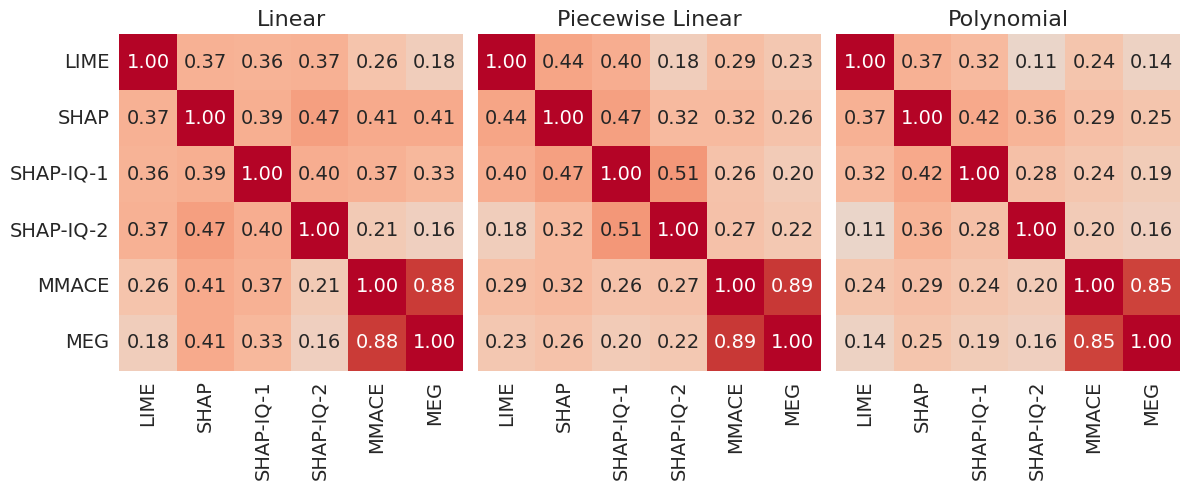

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(12, 5), sharey=True, sharex=True, )

name_data_mapping = {
    'Batteries': 'COF',
    'QM9 Simple Linear': 'Linear',
    'QM9 Piecewise Linear': 'Piecewise Linear',
    'QM9 Nonlinear': 'Polynomial'
}
order_mapping = {
    'Batteries': 3,
    'QM9 Simple Linear': 0,
    'QM9 Piecewise Linear': 1,
    'QM9 Nonlinear': 2
}

for i, (key, data) in enumerate(correlations.items()):
    if key not in name_data_mapping:
        continue
    s = pd.Series(data)
    correlation_matrix = s.unstack()
    name_mapping = {
        'lime': 'LIME',
        'shap': 'SHAP',
        'shapiq1': 'SHAP-IQ-1',
        'shapiq2': 'SHAP-IQ-2',
        'meg': 'MEG',
        'mmace': 'MMACE'
    }
    renamed_matrix = correlation_matrix.rename(index=name_mapping, columns=name_mapping)
    new_order = ['LIME', 'SHAP', 'SHAP-IQ-1', 'SHAP-IQ-2', 'MMACE', 'MEG']
    renamed_matrix = renamed_matrix[new_order].loc[new_order]
    mappable = sns.heatmap(renamed_matrix, annot=True, fmt=".2f", ax=ax[order_mapping[key]], cmap='coolwarm', vmin=-1, vmax=1, cbar=False, annot_kws={'size': 14})

    ax[order_mapping[key]].set_title(name_data_mapping[key], fontsize=16)
    ax[order_mapping[key]].tick_params(axis='both', which='major', labelsize=14)

plt.tight_layout()
plt.savefig('../results/correlation_matrices_gt.pdf', dpi=300, bbox_inches='tight')
plt.show()